# 39 — Structure **expansion** gallery: waking a hidden cause in three worlds

**Where this sits (nb39 of nb38–41).** nb38 was the removal half (BMR pruning edges). This is the
**addition** half: the paper's *expansion* — entertain a commitment not yet in the model. Following
the paper (exploration **is** expansion, no bonus added; Friston et al.), the agent holds an
*agnostic* model that lacks a hidden common cause; it samples a world that has one; the coherent
shift the cause imprints on the commitments it drives **emerges** as a residual; once that residual
clears a trigger the agent **wakes a new node** and wires it in. We watch the Bayes net grow a node,
in **three different worlds**.

**Pipeline (all existing classes, the `run_structure_learning.py` host loop inlined).**
`world_net.true_phlogiston_world` is the true generative `LinearGaussianBN` with a hidden node;
`world_net.agnostic_prior` is the menu that lacks it; each step deposits a node-wise Fisher update
(`world.fisher_deposit` → `belief.add_fisher`), reads the residual from the prediction **errors**
(`action.residual_from_errors` — the footprint a hidden cause leaves when the operator keeps Π
diagonal), proposes a hub (`action.propose_hub`, Eq. 2 backwards), scores `{sample, reduce, expand}`
(`action.select_action`), and on the first accepted expand **wakes** the hub (`action.wake_hub`).

| world | the hidden cause | what we expect |
|---|---|---|
| **A — strong single cause** | one latent driving three *mutually independent* commitments, coupling 1.2 | wakes early, structure recovered |
| **B — faint cause** | the same set, coupling 0.6 | near the discovery threshold — late wake or none |
| **C — different dimension** | a latent over a *different* unconceived triple | a *different* node added |

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig
from src.structural import action, world_net, phlogiston as ph, world
from src.structural.belief import GaussianBeliefNet, add_fisher
from src.structural.world_net import LatentWorldConfig, UNCONCEIVED_DRIVES

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_expansion_gallery'
RESULTS.mkdir(parents=True, exist_ok=True)
cfg = StructuralConfig(n_steps=80, t_shift=200)     # t_shift>n_steps => STATIONARY world (pure accumulation)
TRIGGER = 2.0; HUB_PREC = 2.0; SIGMA = 1.0
print('menu the agent starts with:', cfg.node_names)

menu the agent starts with: ('phlogiston', 'combustion_releases', 'calcination_releases', 'metal_is_calx_plus_phlog', 'mass_change_sign', 'gas_consumed', 'air_has_capacity', 'reduction_with_charcoal', 'respiration_like_combustion', 'calx_heavier_than_metal')


## The wake pipeline (inlined from `scripts/run_structure_learning.py`)

`run_world` traverses the world step by step on the fixed menu, scoring the expansion action each
step, and on the first accepted expand records the woken net. Returns the residual-floor and ΔF
trajectories, the wake step, the woken `(d+1)`-node net, and the structure-recovery F1 (the woken
edges vs the true hidden cause's footprint, `world_net.recovery_scores`).

In [2]:
SUSTAIN = 4               # require a STUBBORN floor (N consecutive expand verdicts), not a one-sample
                          # noise spike -- the small-sample false-positive guard from run_structure_learning.py

def run_world(lw, seed=0, n_steps=None, trigger=TRIGGER):
    n_steps = n_steps or cfg.n_steps
    drives = lw.drives
    meas = ph.measured_nodes(cfg)
    H_node = jnp.asarray(np.asarray(ph.H_observable(cfg)))
    dmeas = [meas.index(n) for n in drives]; dfull = [cfg.node_names.index(n) for n in drives]
    prior = world_net.agnostic_prior(cfg, lw); prior_mean = np.asarray(prior.mean())
    agent = prior; errors = []; key = jax.random.PRNGKey(seed)
    floor_t, dF_t, act_t = [], [], []
    wake_step, woken, f1_un, f1_wo, streak = -1, None, float('nan'), float('nan'), 0
    for t in range(n_steps):
        wnet = world_net.true_phlogiston_world(cfg, t, lw)
        key, k = jax.random.split(key)
        o = np.asarray(world_net.sample_world(wnet, cfg, k))
        errors.append(o[dmeas] - prior_mean[dfull])
        J, j = world.fisher_deposit(H_node, jnp.asarray(o), SIGMA); agent = add_fisher(agent, J, j)
        R = action.residual_from_errors(jnp.asarray(np.array(errors)))
        out = action.select_action(agent, prior, drives, lw.latent_name, prune_edges=(drives[:2],),
                                   residual=R, hub_self_prec=HUB_PREC, trigger=trigger)
        exp = out['expand']; floor_t.append(exp.detail['strength']); dF_t.append(exp.delta_F); act_t.append(out['action'])
        streak = streak + 1 if out['action'] == 'expand' else 0
        if streak >= SUSTAIN and wake_step < 0:
            wake_step = t
            woken = action.wake_hub(agent, out['proposal'], lw.latent_name, hub_self_prec=HUB_PREC)
            f1_un = world_net.recovery_scores(agent, wnet, drives)['edge_f1']
            f1_wo = world_net.recovery_scores(woken, wnet, drives)['edge_f1']
    return dict(floor_t=np.array(floor_t), dF_t=np.array(dF_t), act_t=act_t, wake_step=wake_step,
                prior=prior, woken=woken if woken is not None else agent, agent=agent,
                f1_unwoken=f1_un, f1_woken=f1_wo, drives=drives, name=lw.latent_name)

# a coupling-graph drawer (the woken hub is a latent => undirected |Pi| coupling view)
def draw_couplings(ax, net, pos, title, *, drives=(), hub=None, thr=0.12):
    Pi = np.abs(np.asarray(net.Pi)).copy(); np.fill_diagonal(Pi, 0.0)
    nm = list(net.names); xy = np.array([pos[i] for i in range(len(nm))])
    for a in range(len(nm)):
        for b in range(a + 1, len(nm)):
            if Pi[a, b] > thr:
                is_hub = hub in (nm[a], nm[b])
                ax.plot([xy[a,0], xy[b,0]], [xy[a,1], xy[b,1]],
                        color='seagreen' if is_hub else '0.6',
                        lw=(2.6 if is_hub else 1.0) + 1.5*min(Pi[a,b], 1.0),
                        alpha=0.9 if is_hub else 0.5, zorder=1)
    cols = ['#d8d8d8'] * len(nm)
    for n in drives: cols[nm.index(n)] = 'gold'
    if hub in nm: cols[nm.index(hub)] = 'seagreen'
    ax.scatter(xy[:,0], xy[:,1], c=cols, s=430, edgecolor='k', lw=0.6, zorder=3)
    for i, n in enumerate(nm):
        ax.text(xy[i,0], xy[i,1]-0.12, n[:11]+('…' if len(n) > 12 else ''),
                ha='center', va='top', fontsize=6, zorder=4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal'); ax.margins(0.16)

## A — The gallery: three worlds, three expansion verdicts

Each world's residual floor (the trigger, `λ_max` of the prediction-error covariance) and the
expansion model Bayes factor ΔF, with the wake instant marked. The floor *climbs* as the hidden
cause's coherent shift accumulates; the agent expands when it clears the trigger and ΔF is
favourable — exploration **derived** from the data, not added as a bonus. (A wake also requires the
floor to stay cleared for `SUSTAIN` consecutive steps, so a one-sample noise spike cannot trigger
it — the false-positive guard from `run_structure_learning.py`.)

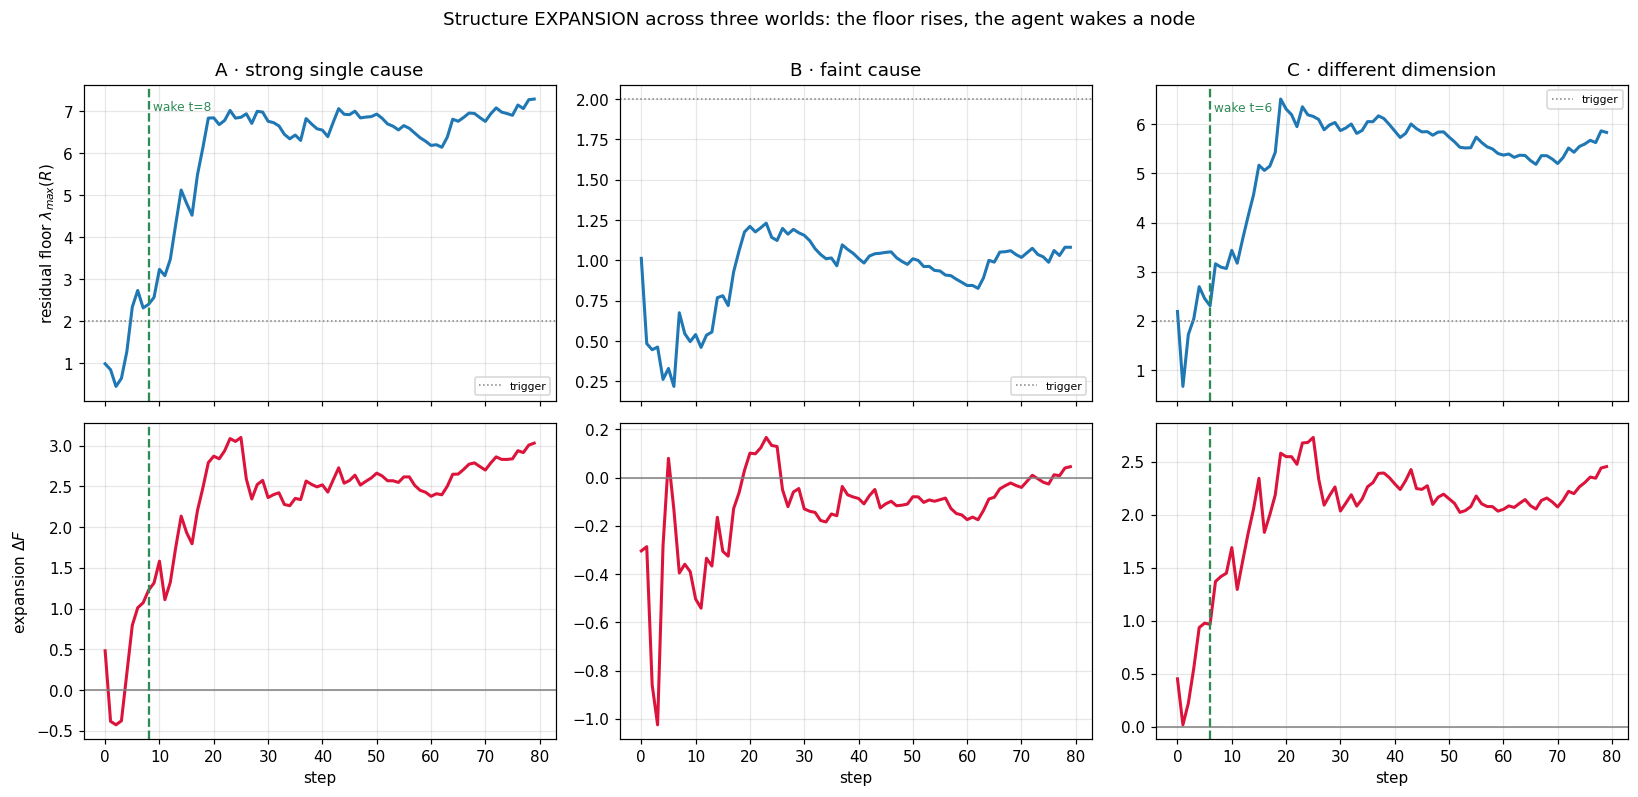

A · strong single cause   : wake at t=  8   edge-F1 0.00 (no hub) -> 1.00 (woken)
B · faint cause           : never woke (floor stayed below trigger 2.0)
C · different dimension   : wake at t=  6   edge-F1 0.00 (no hub) -> 1.00 (woken)


In [3]:
DIFFERENT_TRIPLE = ('combustion_releases', 'calcination_releases', 'metal_is_calx_plus_phlog')
worlds = [
    ('A · strong single cause', LatentWorldConfig(latent_coupling=1.2, latent_mean=1.5,
                                                  drives=UNCONCEIVED_DRIVES, latent_name='caloric')),
    ('B · faint cause',         LatentWorldConfig(latent_coupling=0.6, latent_mean=1.2,
                                                  drives=UNCONCEIVED_DRIVES, latent_name='faint_cause')),
    ('C · different dimension', LatentWorldConfig(latent_coupling=1.0, latent_mean=1.5,
                                                  drives=DIFFERENT_TRIPLE, latent_name='shared_mechanism')),
]
runs = [(ttl, run_world(lw, seed=0)) for ttl, lw in worlds]

fig, axs = plt.subplots(2, 3, figsize=(15, 7.2), sharex=True)
for col, (ttl, r) in enumerate(runs):
    a0, a1 = axs[0, col], axs[1, col]
    a0.plot(r['floor_t'], lw=2); a0.axhline(TRIGGER, color='grey', ls=':', lw=1, label='trigger')
    a1.plot(r['dF_t'], lw=2, color='crimson'); a1.axhline(0, color='grey', lw=1)
    if r['wake_step'] >= 0:
        for a in (a0, a1): a.axvline(r['wake_step'], color='seagreen', ls='--', lw=1.5)
        a0.text(r['wake_step'], a0.get_ylim()[1]*0.92, f" wake t={r['wake_step']}", color='seagreen', fontsize=8)
    a0.set_title(ttl); a0.legend(fontsize=7)
    if col == 0: a0.set_ylabel(r'residual floor $\lambda_{max}(R)$'); a1.set_ylabel(r'expansion $\Delta F$')
    a1.set_xlabel('step')
fig.suptitle('Structure EXPANSION across three worlds: the floor rises, the agent wakes a node', y=1.0)
plt.tight_layout(); plt.savefig(RESULTS / 'A_gallery_floor_dF.png'); plt.show()
for ttl, r in runs:
    ws = r['wake_step']
    if ws >= 0:
        print(f"{ttl:26s}: wake at t={ws:>3}   edge-F1 {r['f1_unwoken']:.2f} (no hub) -> {r['f1_woken']:.2f} (woken)")
    else:
        print(f"{ttl:26s}: never woke (floor stayed below trigger {TRIGGER})")

## B — The node being added (world A, before vs after the wake)

The agnostic prior holds every commitment **independent** (`Π = prec·I`, no edges). The wake
borders a new latent node and wires it to the three commitments the residual loaded on — the Bayes
net *grows a node and a star of couplings* where the joint had zeros. The gold nodes are the driven
commitments; the green node is the woken hidden cause.

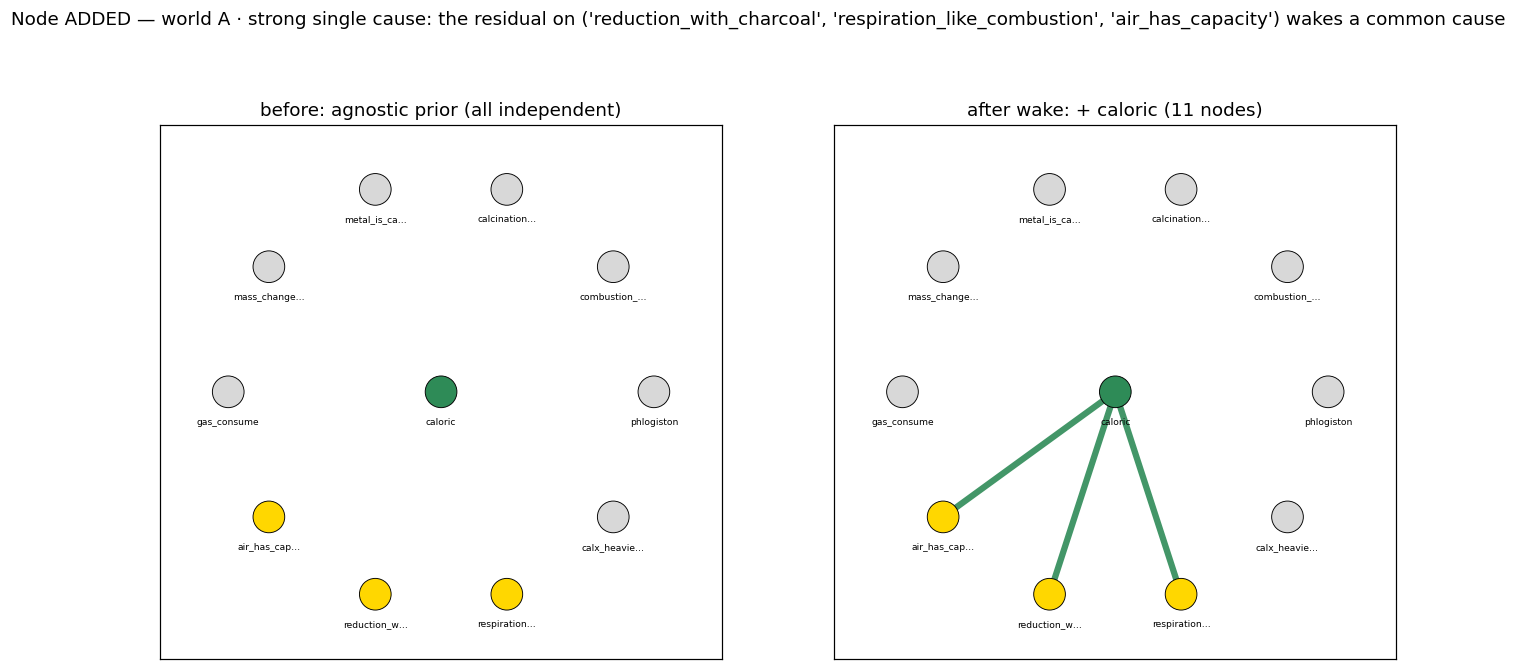

menu dim 10 -> woken dim 11  (new latent node: caloric )


In [4]:
ttlA, rA = runs[0]
prior, woken, drives, hub = rA['prior'], rA['woken'], rA['drives'], rA['name']
# fixed layout over the menu nodes; place the woken hub centrally
import math
nmA = list(woken.names); m = len(cfg.node_names)
th = np.linspace(0, 2*np.pi, m, endpoint=False)
pos = {i: (math.cos(t), math.sin(t)) for i, t in enumerate(th)}
pos[m] = (0.0, 0.0)                                  # the woken hub at the centre
# 'before' uses the same layout but the hub node sits unconnected (prior has no hub)
prior_padded = type(prior)(Pi=jnp.pad(prior.Pi, ((0,1),(0,1))).at[m, m].set(HUB_PREC),
                           h=jnp.pad(prior.h, (0,1)), names=woken.names)
fig, axs = plt.subplots(1, 2, figsize=(14.5, 6.6))
draw_couplings(axs[0], prior_padded, pos, 'before: agnostic prior (all independent)',
               drives=drives, hub=hub)
draw_couplings(axs[1], woken, pos, f'after wake: + {hub} ({woken.dim} nodes)', drives=drives, hub=hub)
fig.suptitle(f'Node ADDED — world {ttlA}: the residual on {drives} wakes a common cause', y=1.02)
plt.savefig(RESULTS / 'B_node_added_world_A.png', bbox_inches='tight'); plt.show()
print('menu dim', prior.dim, '-> woken dim', woken.dim, ' (new latent node:', hub, ')')

## C — The emergent expand/sample boundary

Sweep the hidden cause's coupling strength (the anomaly strength `g`) and read off, over seeds,
the fraction of runs that wake a node and the mean wake step. At `g = 0` (no hidden cause) the
floor never rises and the agent **samples** (the null control); as `g` grows the wake becomes
reliable and earlier — the exploration drive is *derived* from how loud the unconceived dimension
is, exactly the paper's "expansion past a threshold, no posited bonus".

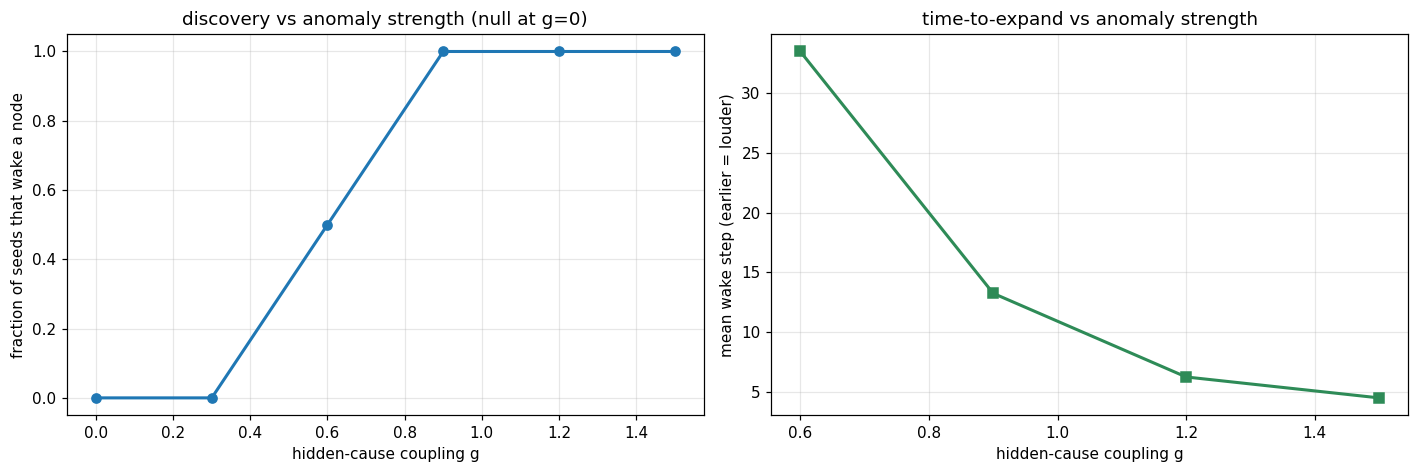

wake fraction by coupling: {0.0: 0.0, 0.3: 0.0, 0.6: 0.5, 0.9: 1.0, 1.2: 1.0, 1.5: 1.0}
null control (g=0): wake fraction = 0.0 (want 0.00)


In [5]:
couplings = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]; seeds = [0, 1, 2, 3]
wake_frac, mean_wake = [], []
for g in couplings:
    woke, steps = [], []
    for sd in seeds:
        lw = LatentWorldConfig(latent_coupling=float(g), latent_mean=1.5,
                               drives=UNCONCEIVED_DRIVES, latent_name='caloric')
        r = run_world(lw, seed=sd, n_steps=60)
        woke.append(r['wake_step'] >= 0)
        if r['wake_step'] >= 0: steps.append(r['wake_step'])
    wake_frac.append(np.mean(woke)); mean_wake.append(np.mean(steps) if steps else np.nan)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(couplings, wake_frac, 'o-', lw=2, ms=6); a0.set_ylim(-0.05, 1.05)
a0.set_xlabel('hidden-cause coupling g'); a0.set_ylabel('fraction of seeds that wake a node')
a0.set_title('discovery vs anomaly strength (null at g=0)')
a1.plot(couplings, mean_wake, 's-', lw=2, ms=6, color='seagreen')
a1.set_xlabel('hidden-cause coupling g'); a1.set_ylabel('mean wake step (earlier = louder)')
a1.set_title('time-to-expand vs anomaly strength')
plt.tight_layout(); plt.savefig(RESULTS / 'C_expand_boundary.png'); plt.show()
print('wake fraction by coupling:', dict(zip(couplings, [round(float(x), 2) for x in wake_frac])))
print('null control (g=0): wake fraction =', round(float(wake_frac[0]), 2), '(want 0.00)')

## Verdict

The addition half of structure learning, as a gallery and on the existing classes
(`world_net` + `action`, the `run_structure_learning.py` host loop):

* a hidden cause the menu lacks leaves a **coherent residual that emerges** from sampled data; the
  floor rises and the agent **wakes a new node** — the Bayes net grows (§A, §B), drawn as the star
  of couplings appearing where the agnostic prior had only isolated commitments;
* the wake is **earned by three different worlds** — a strong cause (early wake, structure
  recovered), a faint one (near threshold), and a cause on a *different* unconceived triple (a
  different node added);
* the **expand/sample boundary is emergent** (§C): no wake at `g = 0` (the null), reliable and
  earlier wakes as the unconceived dimension grows louder — exploration *derived*, not a bonus.

Honest caveat carried from `run_structure_learning.py`: the wake finds the right edges and sign,
but its PD-safe coupling magnitude is a heuristic that can overshoot the true value, so recovery is
judged on edge-F1 (structure), not on the coupling magnitude.

Next (nb40): both moves on **one** trajectory — a node added, then an edge removed.